# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Isabella Mazzei
* Username: ibmazzei
* Student number: s6253636
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
import sympy as sp
from scipy.integrate import quad

class Integrator:
    def __init__(self, func_str, a, b):
        # Store the function string and the interval limits
        self.func_str = func_str
        self.a = a
        self.b = b

    def evaluate(self, x):
        # Evaluate the function at a given x value
        return eval(self.func_str, {"x": x, "sin": np.sin, "pi": np.pi})

    #  Trapezium Rule 
    def trapezium(self, n=1000):
        h = (self.b - self.a) / n          # step size
        total = 0
        for i in range(n):
            x0 = self.a + i * h
            x1 = self.a + (i + 1) * h
            total += 0.5 * h * (self.evaluate(x0) + self.evaluate(x1))  # trapezium formula
        return total

    # Simpson's Rule
    def simpsons(self, n=100):
        # n must be even for Simpson's rule
        if n % 2 != 0:
            n += 1
        h = (self.b - self.a) / n          # step size
        total = self.evaluate(self.a) + self.evaluate(self.b)  # first and last terms
        for i in range(1, n):
            x = self.a + i * h
            if i % 2 == 0:
                total += 2 * self.evaluate(x)   # even terms multiplied by 2
            else:
                total += 4 * self.evaluate(x)   # odd terms multiplied by 4
        return (h / 3) * total

    #  Monte Carlo Integration 
    def monte_carlo(self, n=100000):
        np.random.seed(42)                              # so results are reproducible
        x_random = np.random.uniform(self.a, self.b, n) # random x points in [a, b]
        y_values = self.evaluate(x_random)               # evaluate function at each point
        return (self.b - self.a) * np.mean(y_values)    # Monte Carlo formula

    # SymPy Exact Integration 
    def sympy_integrate(self):
        x = sp.Symbol('x')
        expr = 1 + x + 2 * sp.sin(x)      # define the function symbolically
        result = sp.integrate(expr, (x, self.a, self.b))  # exact integration
        return float(result)

    # SciPy Integration
    def scipy_integrate(self):
        result, _ = quad(self.evaluate, self.a, self.b)  # quad returns (result, error)
        return result


#Test with a=0.5, b=3.0 
integrator = Integrator("1 + x + 2*sin(x)", a=0.5, b=3.0)

print("Trapezium Rule:  ", integrator.trapezium())
print("Simpson's Rule:  ", integrator.simpsons())
print("Monte Carlo:     ", integrator.monte_carlo())
print("SymPy:           ", integrator.sympy_integrate())
print("SciPy:           ", integrator.scipy_integrate())

Trapezium Rule:   10.610148171590748
Simpson's Rule:   10.610150125088033
Monte Carlo:      10.610267629603989
SymPy:            10.610150116981636
SciPy:            10.610150116981638


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

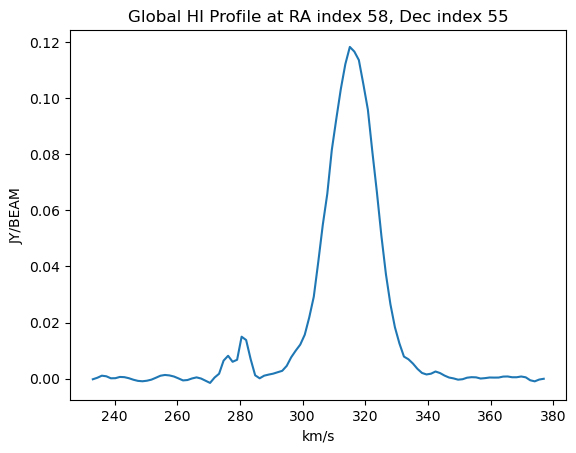

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file and read the data and header
hdul = fits.open("ngc6946.fits")
data = hdul[0].data      # the 3D cube (channels, y, x)
header = hdul[0].header  # the header with metadata

# Extract the profile at x=58, y=55 (all 101 channels)
profile = data[:, 55, 58]

# Convert pixel index to km/s using linspace
velocity = np.linspace(233, 377, len(profile))

# Get axis labels from the header
x_label = header["CUNIT3"]   # velocity unit
y_label = header["BUNIT"]    # intensity unit

# Plot the profile
plt.figure()
plt.plot(velocity, profile)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("Global HI Profile at RA index 58, Dec index 55")
plt.show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
def f(x, amp, mu, sigma, zero):
    # Gaussian formula with a vertical offset (zero)
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + zero

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [8]:
# A model is linear if ALL its derivatives with respect to its parameters are
# independent of those parameters.
#
# Take the derivative of f with respect to mu:
#   df/dmu = amp * ((x - mu) / sigma^2) * exp(-0.5 * ((x - mu) / sigma)^2)
#
# This derivative still contains mu inside it.
# Therefore the model is NON-LINEAR — the derivatives depend on the parameters.

In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [10]:
from scipy.optimize import curve_fit

# Initial estimates (p0):
# amp   ~ 0.12  → eyeballing the peak height from the plot
# mu    ~ 310   → the peak looks to be around 310 km/s
# sigma ~ 20    → the peak looks roughly 40 km/s wide, sigma is about half of that
# zero  ~ 0.0   → the baseline looks close to zero

p0 = [0.12, 310, 20, 0.0]

# Run the fit
popt, pcov = curve_fit(f, velocity, profile, p0=p0)

# Get standard errors from the covariance matrix
perr = np.sqrt(np.diag(pcov))

# Print results
print("Best fit parameters:")
print(f"  amp   = {popt[0]:.5f} +/- {perr[0]:.5f}")
print(f"  mu    = {popt[1]:.3f} +/- {perr[1]:.3f} km/s")
print(f"  sigma = {popt[2]:.3f} +/- {perr[2]:.3f} km/s")
print(f"  zero  = {popt[3]:.5f} +/- {perr[3]:.5f}")

Best fit parameters:
  amp   = 0.11694 +/- 0.00110
  mu    = 315.717 +/- 0.077 km/s
  sigma = 7.261 +/- 0.082 km/s
  zero  = 0.00134 +/- 0.00031


In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

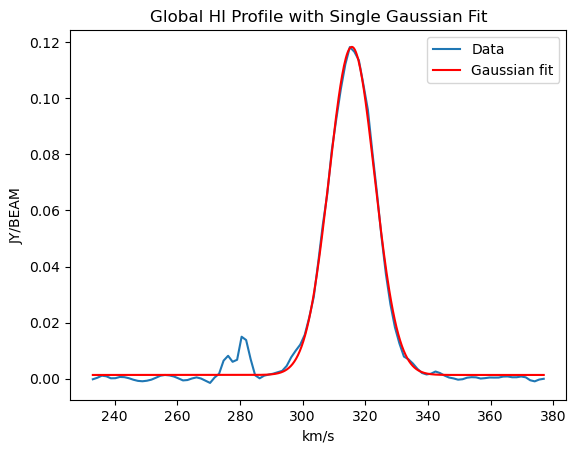

In [12]:
# Generate smooth curve using best fit parameters
x_smooth = np.linspace(233, 377, 500)
y_fit = f(x_smooth, *popt)   # *popt unpacks the 4 parameters

plt.figure()
plt.plot(velocity, profile, label="Data")
plt.plot(x_smooth, y_fit, label="Gaussian fit", color="red")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("Global HI Profile with Single Gaussian Fit")
plt.legend()
plt.show()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

Double Gaussian best fit parameters:
  Main peak:      amp=0.11753, mu=315.715, sigma=7.335
  Secondary peak: amp=0.01173, mu=280.247, sigma=3.022


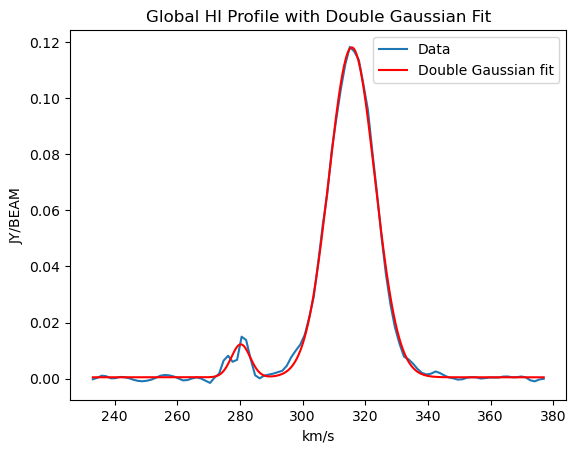

In [14]:
# Define a model with TWO Gaussians sharing one zero offset
def f2(x, amp1, mu1, sigma1, amp2, mu2, sigma2, zero):
    gauss1 = amp1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)  # main peak
    gauss2 = amp2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)  # small secondary peak
    return gauss1 + gauss2 + zero

# Initial estimates for both peaks
# Second small peak looks to be around 250 km/s, smaller amplitude
p0_2 = [0.12, 315, 7, 0.02, 280, 5, 0.0]

# bounds make sure amp and sigma stay positive
bounds = ([0, 280, 0, 0, 250, 0, -np.inf],   # lower bounds
          [np.inf, 340, np.inf, np.inf, 300, np.inf, np.inf])  # upper bounds

popt2, pcov2 = curve_fit(f2, velocity, profile, p0=p0_2, bounds=bounds)

print("Double Gaussian best fit parameters:")
print(f"  Main peak:      amp={popt2[0]:.5f}, mu={popt2[1]:.3f}, sigma={popt2[2]:.3f}")
print(f"  Secondary peak: amp={popt2[3]:.5f}, mu={popt2[4]:.3f}, sigma={popt2[5]:.3f}")

# Plot
y_fit2 = f2(x_smooth, *popt2)

plt.figure()
plt.plot(velocity, profile, label="Data")
plt.plot(x_smooth, y_fit2, label="Double Gaussian fit", color="red")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("Global HI Profile with Double Gaussian Fit")
plt.legend()
plt.show()

In [15]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [17]:
perr2 = np.sqrt(np.diag(pcov2))   # standard errors for double gaussian
# FWHM = 2 * sqrt(2 * ln(2)) * sigma
fwhm_factor = 2 * np.sqrt(2 * np.log(2))

# FWHM for main peak (index 2) and secondary peak (index 5)
fwhm_main = fwhm_factor * popt2[2]
fwhm_sec  = fwhm_factor * popt2[5]

# Standard errors in FWHM (same factor applied to sigma errors)
fwhm_main_err = fwhm_factor * perr2[2]
fwhm_sec_err  = fwhm_factor * perr2[5]

print(f"FWHM main peak:      {fwhm_main:.3f} +/- {fwhm_main_err:.3f} km/s")
print(f"FWHM secondary peak: {fwhm_sec:.3f}  +/- {fwhm_sec_err:.3f}  km/s")

FWHM main peak:      17.272 +/- 0.110 km/s
FWHM secondary peak: 7.116  +/- 0.684  km/s


In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

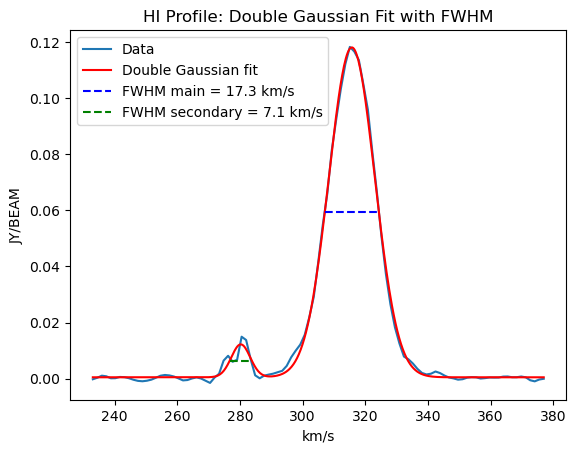

In [19]:
plt.figure()

# Data and fit
plt.plot(velocity, profile, label="Data")
plt.plot(x_smooth, y_fit2, color="red", label="Double Gaussian fit")

# FWHM horizontal lines at the center of each peak
half_max_main = popt2[0] / 2 + popt2[6]   # half of main amplitude + zero offset
half_max_sec  = popt2[3] / 2 + popt2[6]   # half of secondary amplitude + zero offset

plt.hlines(half_max_main,
           popt2[1] - fwhm_main / 2,
           popt2[1] + fwhm_main / 2,
           colors="blue", linestyles="dashed",
           label=f"FWHM main = {fwhm_main:.1f} km/s")

plt.hlines(half_max_sec,
           popt2[4] - fwhm_sec / 2,
           popt2[4] + fwhm_sec / 2,
           colors="green", linestyles="dashed",
           label=f"FWHM secondary = {fwhm_sec:.1f} km/s")

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title("HI Profile: Double Gaussian Fit with FWHM")
plt.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   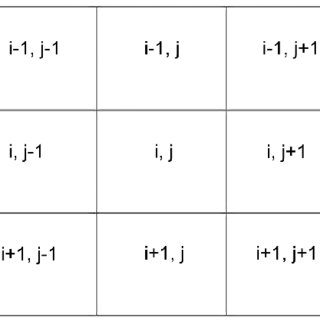    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

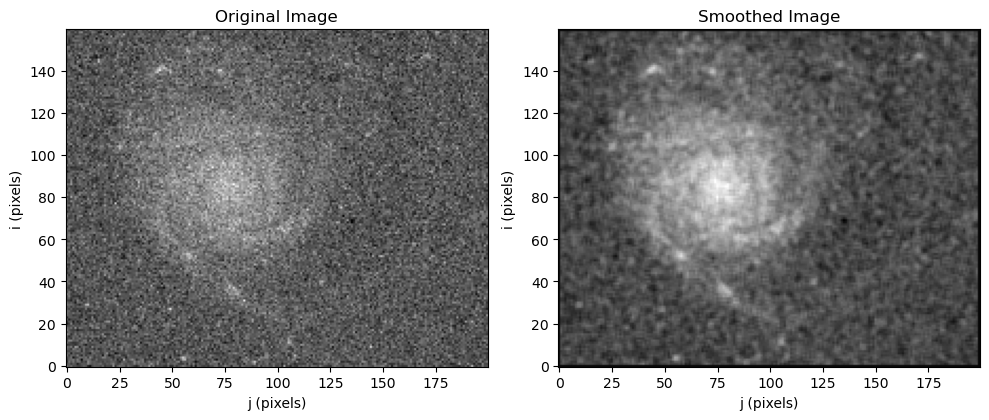

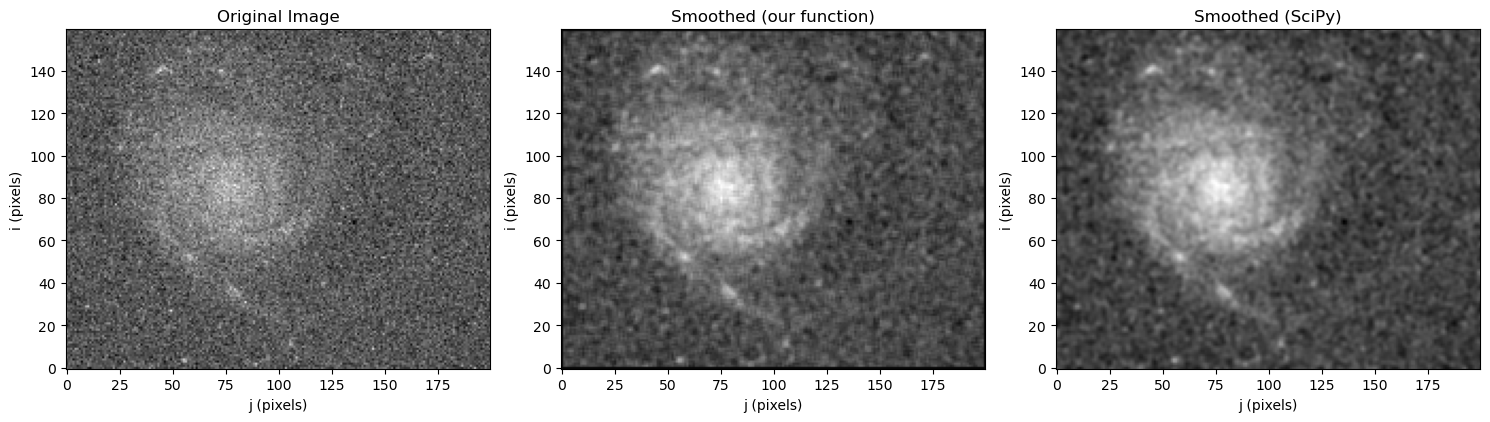

In [18]:
import numpy as np
from astropy.io import fits
from scipy import ndimage
import matplotlib.pyplot as plt

# Open the FITS file and read the image
hdul = fits.open("faintgalaxy.fits")
M = hdul[0].data   # the 2D image

#  Part 1: smooth() function
def smooth(M):
    # Create a new empty image of the same shape, filled with zeros
    Mc = np.zeros_like(M)
    
    ni, nj = M.shape  # ni = number of rows, nj = number of columns
    
    # Loop through every pixel except the borders
    for i in range(1, ni - 1):
        for j in range(1, nj - 1):
            # Extract the 3x3 box around pixel (i, j) and take the mean
            Mc[i, j] = np.mean(M[i-1:i+2, j-1:j+2])
    
    return Mc

# Part 2: Mosaic with original and smoothed image 
M_smoothed = smooth(M)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
axes[0].imshow(M, origin="lower", cmap="gray")
axes[0].set_title("Original Image")
axes[0].set_xlabel("j (pixels)")
axes[0].set_ylabel("i (pixels)")

# Smoothed image
axes[1].imshow(M_smoothed, origin="lower", cmap="gray")
axes[1].set_title("Smoothed Image")
axes[1].set_xlabel("j (pixels)")
axes[1].set_ylabel("i (pixels)")

plt.tight_layout()
plt.show()

# Part 3: SciPy smooth2() function and plot
def smooth2(M):
    # SciPy's built-in Gaussian smoothing with sigma=1 in both directions
    Mc = ndimage.gaussian_filter(M, sigma=(1, 1), order=0)
    return Mc

M_smoothed2 = smooth2(M)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(M, origin="lower", cmap="gray")
axes[0].set_title("Original Image")
axes[0].set_xlabel("j (pixels)")
axes[0].set_ylabel("i (pixels)")

# Our smooth()
axes[1].imshow(M_smoothed, origin="lower", cmap="gray")
axes[1].set_title("Smoothed (our function)")
axes[1].set_xlabel("j (pixels)")
axes[1].set_ylabel("i (pixels)")

# SciPy smooth2()
axes[2].imshow(M_smoothed2, origin="lower", cmap="gray")
axes[2].set_title("Smoothed (SciPy)")
axes[2].set_xlabel("j (pixels)")
axes[2].set_ylabel("i (pixels)")

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")